In [2]:
import load_fcn
import os
import numpy as np


path=os.path.join('Downloaded_data','Dlx1','figshare_14959449')

sf, expName, ref_channels, dead_channels = load_fcn.load_info(path)
channels_map = load_fcn.load_channels_map(path)
dsf = 1250

# Reformat channels into correct values
channels, shanks, ref_channels = load_fcn.reformat_channels(channels_map, ref_channels)
# Read .dat
print('Channel map value: ',channels)
LFP = load_fcn.load_raw_data(path, expName, channels, verbose=True)
print('Sampling frequency: ', sf)
print('Shape of the original data',LFP.shape)
print(channels_map)

import proc_fcn
# The loaded LFP already contains the requested channels, so use its column indices
lfp_channels = np.arange(LFP.shape[1])

# Interpolate missing channels, downsample, and z-score each channel
LFP_norm = proc_fcn.process_LFP(
    LFP,
    sf=sf,
    d_sf=dsf,
    channels=lfp_channels,
)

print("Preprocessed LFP shape:", LFP_norm.shape)
print("Preprocessed LFP dtype:", LFP_norm.dtype)

Channel map value:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Downloaded_data\Dlx1\figshare_14959449/lfp_Dlx1-2021-02-12_12-46-54.dat
fileStart  0
fileStop  490242048
nSamples  245121024
nSamplesPerChannel  30640128
nSamplesPerChunk  10000
size data  30640128
Sampling frequency:  30000
Shape of the original data (30640128, 8)
[[1 1 2]
 [2 1 2]
 [3 1 2]
 [4 1 2]
 [5 1 2]
 [6 1 2]
 [7 1 2]
 [8 1 2]]
Downsampling data from 30000 to 1250 Hz...
Shape of downsampled data: (1276672, 8)
Normalizing data...
Preprocessed LFP shape: (1276672, 8)
Preprocessed LFP dtype: float16


In [32]:
from ripple_detection import Karlsson_ripple_detector,filter_ripple_band
# for the parida lab data, I might need to make fake timestamps and speed
speed = np.zeros(LFP_norm.shape[0])
time = np.arange(LFP_norm.shape[0]) / dsf
sampling_frequency = dsf

filtered_LFPs = filter_ripple_band(LFP_norm, sampling_frequency)
# Detect ripples with custom parameters
ripples = Karlsson_ripple_detector(
    time, filtered_LFPs[:,4:5], speed, sampling_frequency,
    speed_threshold=4.0,
    minimum_duration=0.015,
    zscore_threshold=3.0,
    smoothing_sigma=0.004,
    close_ripple_threshold=0.0
)

# Access detailed statistics
print(f"Detected {len(ripples)} ripple events")
print(f"Mean duration: {ripples['duration'].mean():.3f} seconds")
print(f"Max duration: {ripples['duration'].max():.3f} seconds")
print(f"Mean z-score: {ripples['mean_zscore'].mean():.2f}")

C:\Users\lilytong\AppData\Local\Temp\ipykernel_22876\143522737.py:7: UserWarning: The pre-computed ripple filter is optimized for 1500.0 Hz sampling.
Your data: 1250 Hz. Results may be suboptimal.
For best results, use ripple_bandpass_filter(1250) to generate a custom filter.
  filtered_LFPs = filter_ripple_band(LFP_norm, sampling_frequency)


Detected 234 ripple events
Mean duration: 0.108 seconds
Max duration: 0.264 seconds
Mean z-score: 3.18


# Compare with true set 

In [4]:
import load_fcn
import os
path=os.path.join('Downloaded_data','Dlx1','figshare_14959449')
sf, expName, ref_channels, dead_channels = load_fcn.load_info(path)
# load ripple indices from the figshare dataset
true = load_fcn.load_ripples(r"F:\GitHub\rippl-AI\Downloaded_data\Dlx1\figshare_14959449")/sf
# reformat prediction to match the function input
predicted = ripples.loc[:,["start_time","end_time"]].values
print("True ripples:", type(true), true.shape)
print("Predicted ripples:", type(predicted), predicted.shape)

# make the comparison
percision, recall, F1, TP, FN, IOU = get_performance(predicted, true, threshold=0.0, exclude_matched_trues=False, verbose=True)

True ripples: <class 'numpy.ndarray'> (211, 2)
Predicted ripples: <class 'numpy.ndarray'> (234, 2)
precision = 0.7435897435897436
recall = 0.8483412322274881
F1 = 0.7925190839694656


Number of true positives: 174
Number of false positives: 60
Number of false negatives: 32


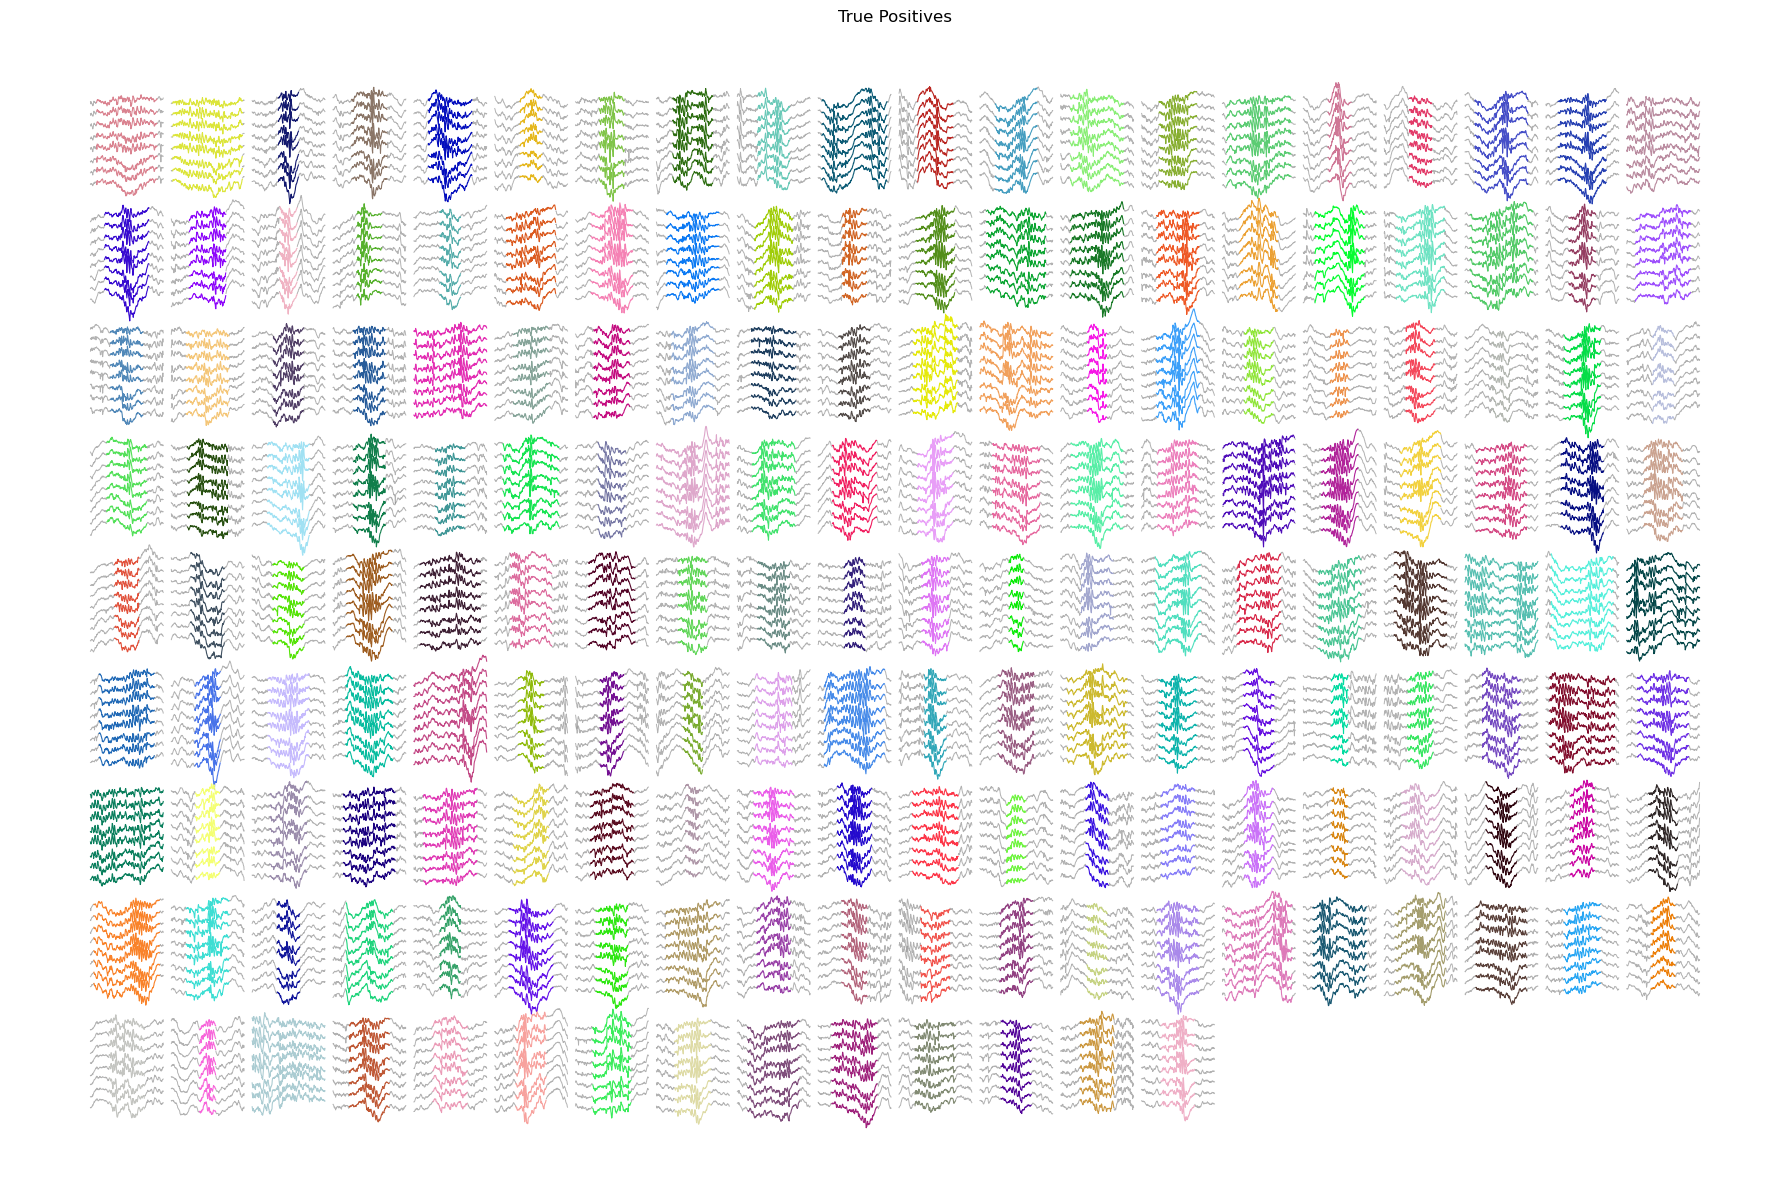

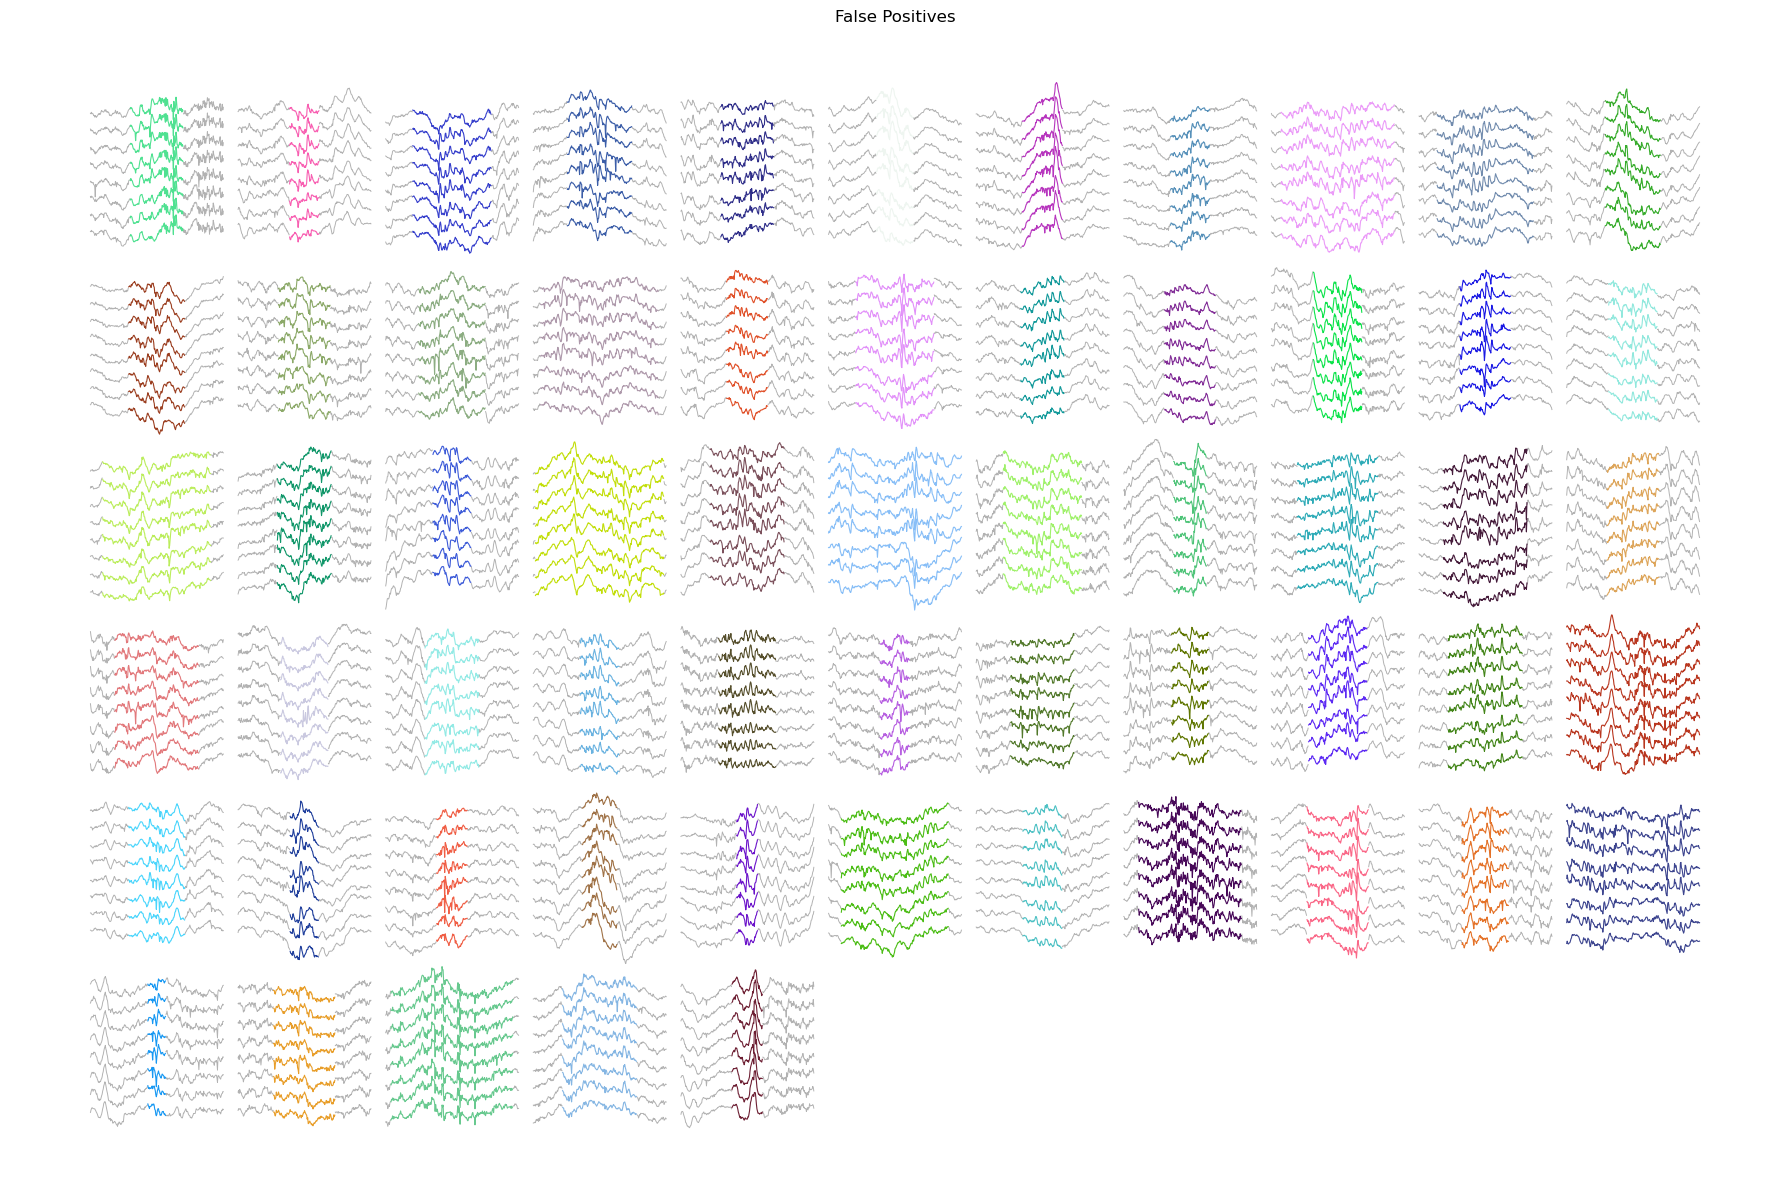

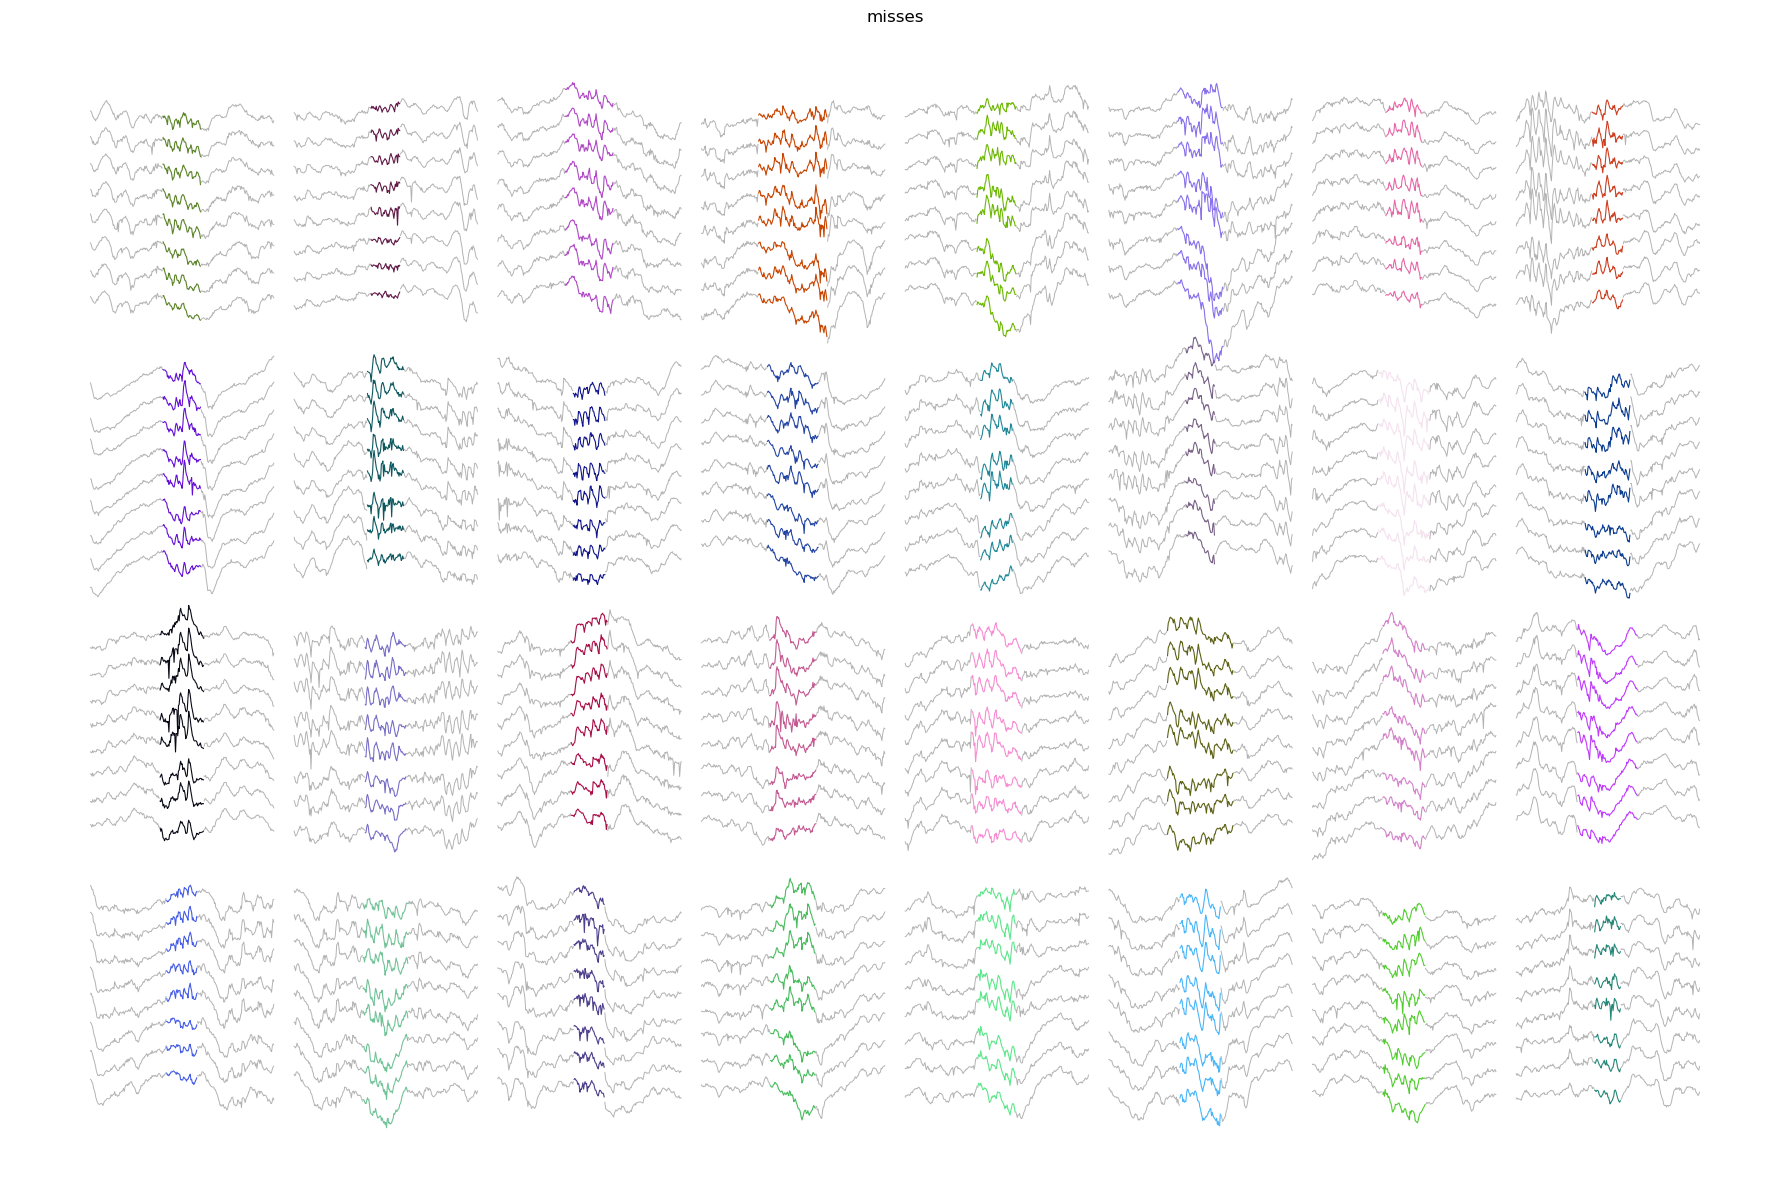

In [62]:
# visualize examples of True positives and false positives
import numpy as np
from eval_fcn import get_performance, plot_all_events

# mid = (predicted[:,1] - predicted[:,0])/2 + predicted[:,0]
id_tp = np.where(TP)[0]
id_fp = np.where(~TP)[0]
id_fn = np.where(FN)[1]

print(f"Number of true positives: {len(id_tp)}")
print(f"Number of false positives: {len(id_fp)}")
print(f"Number of false negatives: {len(id_fn)}")

# Plot true positives
plot_all_events(predicted[id_tp, :], LFP_norm, dsf, title='True Positives')
    
# Plot false positives
plot_all_events(predicted[id_fp, :], LFP_norm, dsf, title='False Positives')

# maybe plot misses too, this index should be for the true sets
plot_all_events(true[id_fn, :], LFP_norm, dsf, title='misses')

# Allen data

In [ ]:
# load data
import numpy as np
lfp_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_754312389_756781561.npy"
time_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_time_754312389_756781561.npy"
speed_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_speed_754312389_756781561.npy"

LFPs = np.load(lfp_path)  # Load LFP data from .npy file
time = np.load(time_path)  # Load time data from .npy file
speed = np.load(speed_path)

# time = np.arange(0, 10, 0.001)  # 10 seconds at 1000 Hz
# LFPs = np.random.randn(len(time), 4)  # 4 channels of LFP data
# speed = np.abs(np.random.randn(len(time)))  # Animal speed
sampling_frequency = 1250  # Hz

from ripple_detection import Kay_ripple_detector

# Detect ripples
ripple_times = Kay_ripple_detector(
    time, LFPs, speed, sampling_frequency,
    speed_threshold=4.0,        # cm/s
    minimum_duration=0.015,     # seconds
    zscore_threshold=2.0
)

from ripple_detection import Karlsson_ripple_detector,filter_ripple_band

# Detect ripples with custom parameters
ripples = Karlsson_ripple_detector(
    time, LFPs[:,4:5], speed, sampling_frequency,
    speed_threshold=4.0,
    minimum_duration=0.015,
    zscore_threshold=3.0,
    smoothing_sigma=0.004,
    close_ripple_threshold=0.0
)

# Access detailed statistics
print(f"Detected {len(ripples)} ripple events")
print(f"Mean duration: {ripples['duration'].mean():.3f} seconds")
print(f"Mean z-score: {ripples['mean_zscore'].mean():.2f}")
